# Egyptian Hieroglyph Recognition — Sign + Direction Classifier

ConvNeXt-Base · dual-head (sign + reading direction) · 5-fold CVV ensemble · 162 Gardiner classes.

## What changed in this version — the artifact-classification fix

The data-leakage and overfitting fixes from the previous version are correct and are kept as-is: stratified test split, `StratifiedKFold`, a `WeightedRandomSampler` (no physical duplication of rare images), discriminative learning rates, drop-path / dropout / weight-decay, validation macro-F1 checkpointing, and an MD5 identical-image leakage check. Held-out test accuracy is genuine.

The remaining bug was **not** in the model — it was in **image preprocessing**, and it only showed up on real segmented crops.

The previous version resized every crop with a **stretch to a square** (`Resize((224, 224))`), which scales width and height independently. A tightly-cropped tall, narrow glyph (e.g. the reed **M17**) gets its width blown up several times, so the glyph is squashed wide and its proportions start to match a genuinely wide sign (e.g. **D55**). A looser, wider crop of the same glyph is distorted far less, so it stays correct. Because the segmentation stage produces crops whose aspect ratio depends on each glyph's bounding box, the **same glyph flips class depending on how thin the crop is** — exactly the M17 → D55 failure.

The fix is an **aspect-preserving letterbox**: scale the longest side to 224 (**upscaling allowed**, unlike the old `thumbnail` that could only shrink), then pad to a square with the crop's own median border colour so the padding blends with the background instead of being a hard black frame. The identical transform is used for **training and inference**, so a thin reed always looks like a thin reed regardless of crop tightness, and tiny crops are no longer dropped into a mostly-empty frame. Because `predict_crops` (the full-pipeline batch classifier) calls `val_tfm`, the fix propagates to the segmentation → classification path automatically.

> Re-run the whole notebook (retrain). The weights are tied to the preprocessing; changing only inference would create a train/serve mismatch.

### Dependencies

In [1]:
!pip install timm scikit-learn ipywidgets -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 80.2 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

## Configuration & hyper-parameters

In [2]:
import os, sys, json, math, random, shutil, glob, warnings, time, io
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageOps
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torch.amp import autocast, GradScaler

import timm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, precision_recall_fscore_support,
)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark     = True

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
print("Device:", DEVICE, "| GPUs:", torch.cuda.device_count(), "| AMP:", USE_AMP)

DATASET_ROOT = "/kaggle/input/datasets/mennaalaarasslan/egyptian-hieroglyphic-text/Glyph2025"
ANNOTATION_CANDIDATES = [
    "/kaggle/input/datasets/freedie28/annotations-final/annotations_final_corrected.csv"
]
ANNOTATIONS_CSV = next((p for p in ANNOTATION_CANDIDATES if os.path.exists(p)), None)
if ANNOTATIONS_CSV is None:
    raise FileNotFoundError(f"annotations CSV not found. Tried: {ANNOTATION_CANDIDATES}")

DIRECTIONS     = ["dual", "left", "right"]
DIR_TO_IDX     = {d: i for i, d in enumerate(DIRECTIONS)}
IDX_TO_DIR     = {i: d for d, i in DIR_TO_IDX.items()}
NUM_DIRECTIONS = len(DIRECTIONS)

OFFICIAL_CLASSES = {
    'a1','a2','a19','a24','a30','a40','a42','a50','b1',
    'd1','d2','d4','d21','d28','d35','d36','d37','d39','d40','d45','d46','d52','d54','d55','d56','d58','d60',
    'e1','e7','e21','e23','e34',
    'f1','f4','f12','f13','f18','f21','f26','f31','f32','f34','f35','f39',
    'g1','g5','g7','g14','g17','g25','g35','g36','g37','g38','g39','g40','g43',
    'h1','h6','h8','i1','i9','i10','l1','l2',
    'm2','m3','m12','m16','m17','m18','m20','m22','m23','m42',
    'n1','n5','n8','n14','n18','n25','n26','n29','n30','n31','n33','n35','n36','n37','n42',
    'o1','o3','o4','o6','o28','o29','o34','o49','o50','p8','q1','q2','q3',
    'r4','r7','r8','r11','r14',
    's3','s19','s21','s24','s27','s28','s29','s34','s38','s40','s42',
    't21','t22','t28','u1','u6','u7','u15','u23','u33',
    'v1','v4','v6','v7','v10','v13','v20','v28','v29','v30','v31',
    'w11','w14','w15','w17','w18','w19','w22','w23','w24','w25',
    'x1','x7','x8','y1','y2','y3','y4','y5','z1','z2','z3','z4','z11','aa13','aa15'
}

CONVNEXT_BACKBONE = "convnext_base"
IMG_SIZE          = 224
K_FOLDS           = 5
CLF_EPOCHS        = 25
CLF_BATCH         = 32
PATIENCE          = 6

LR_BACKBONE       = 5e-5
LR_HEAD           = 1e-4
WEIGHT_DECAY      = 3e-2
WARMUP_EPOCHS     = 3

DROP_PATH_RATE    = 0.10
HEAD_DROPOUT      = 0.20
LABEL_SMOOTH_SIGN = 0.10
LABEL_SMOOTH_DIR  = 0.05
DIR_LOSS_WEIGHT   = 0.7

USE_MIXUP         = False
MIXUP_ALPHA       = 0.2
MIXUP_P           = 0.5

MIN_IMGS_PER_CLS  = 7

os.makedirs("cvv_models", exist_ok=True)
os.makedirs("results",    exist_ok=True)
print("Config ready. Backbone:", CONVNEXT_BACKBONE, "| IMG_SIZE:", IMG_SIZE, "| MixUp:", USE_MIXUP)


Device: cuda | GPUs: 2 | AMP: True
Config ready. Backbone: convnext_base | IMG_SIZE: 224 | MixUp: False


## Build the sample list from the dataset + annotations

In [3]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
disk_class_dirs = sorted(d for d in os.listdir(DATASET_ROOT)
                         if os.path.isdir(os.path.join(DATASET_ROOT, d)))
disk_lookup = {d.lower(): d for d in disk_class_dirs}

ann = pd.read_csv(ANNOTATIONS_CSV)
print("Annotation rows :", len(ann), "| columns:", ann.columns.tolist())

PREFIX = "Glyph2025/"
def strip_prefix(p):
    if not isinstance(p, str): return None
    p = p.replace("\\", "/")
    idx = p.lower().find(PREFIX.lower())
    return None if idx == -1 else p[idx + len(PREFIX):]

ann["rel_path"] = ann["image_path"].apply(strip_prefix)
ann = ann.dropna(subset=["rel_path", "gardiner_code", "direction"]).copy()

def resolve_path(rel):
    parts = rel.split("/", 1)
    if len(parts) != 2: return None
    folder_lc, fname = parts[0].lower(), parts[1]
    real_folder = disk_lookup.get(folder_lc)
    if real_folder is None: return None
    cand = os.path.join(DATASET_ROOT, real_folder, fname)
    if os.path.exists(cand): return cand
    folder_full = os.path.join(DATASET_ROOT, real_folder); fl = fname.lower()
    for f in os.listdir(folder_full):
        if f.lower() == fl: return os.path.join(folder_full, f)
    return None

ann["abs_path"] = ann["rel_path"].apply(resolve_path)
ann = ann.dropna(subset=["abs_path"]).copy()
ann["folder"]   = ann["abs_path"].apply(lambda p: os.path.basename(os.path.dirname(p)))

class_counts = ann["folder"].value_counts()
keep_min7    = class_counts[class_counts >= MIN_IMGS_PER_CLS].index.tolist()
keep_classes = [c for c in keep_min7 if c.lower() in OFFICIAL_CLASSES]
ann = ann[ann["folder"].isin(keep_classes)].copy()
ann = ann[ann["direction"].isin(DIRECTIONS)].copy()

CLASS_NAMES  = sorted(keep_classes)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(CLASS_NAMES)

ann["sign_idx"] = ann["folder"].map(CLASS_TO_IDX)
ann["dir_idx"]  = ann["direction"].map(DIR_TO_IDX)
print("Final classes:", NUM_CLASSES, "| usable samples:", len(ann))
print("Direction distribution:", {DIRECTIONS[i]: int((ann["dir_idx"]==i).sum()) for i in range(NUM_DIRECTIONS)})


Annotation rows : 13721 | columns: ['image_path', 'gardiner_code', 'direction', 'annotated_by', 'source']
Final classes: 162 | usable samples: 13155
Direction distribution: {'dual': 8578, 'left': 808, 'right': 3769}


## Stratified split + StratifiedKFold

A stratified 90/10 split holds out a test set, then `StratifiedKFold(5)` builds the cross-validation folds on the train+val pool only. The split happens on the raw image list before any balancing, and an explicit overlap assertion in the training loop guarantees no image appears in both a train and a val fold.

In [4]:
samples_df = ann[["abs_path", "sign_idx", "dir_idx"]].reset_index(drop=True)

trainval_df, test_df = train_test_split(
    samples_df, test_size=0.10, random_state=SEED, stratify=samples_df["sign_idx"]
)
trainval_df = trainval_df.reset_index(drop=True)
test_df     = test_df.reset_index(drop=True)

def df_to_samples(d):
    return list(zip(d["abs_path"].tolist(),
                    d["sign_idx"].astype(int).tolist(),
                    d["dir_idx"].astype(int).tolist()))

test_samples_raw = df_to_samples(test_df)

try:
    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    fold_splits = list(skf.split(trainval_df["abs_path"], trainval_df["sign_idx"]))
    print("StratifiedKFold OK")
except ValueError as e:
    from sklearn.model_selection import KFold
    print("StratifiedKFold failed (", e, ") -> falling back to KFold")
    fold_splits = list(KFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
                       .split(trainval_df["abs_path"]))

print(f"Train+Val: {len(trainval_df)} | Test: {len(test_df)} | Folds: {len(fold_splits)}")

raw_dir_counts = Counter(trainval_df["dir_idx"].tolist())
Ntot = sum(raw_dir_counts.values())
DIR_CLASS_WEIGHTS = torch.tensor(
    [Ntot / (NUM_DIRECTIONS * max(raw_dir_counts[i], 1)) for i in range(NUM_DIRECTIONS)],
    dtype=torch.float)
print("Direction weights:", {DIRECTIONS[i]: round(DIR_CLASS_WEIGHTS[i].item(),3) for i in range(NUM_DIRECTIONS)})


StratifiedKFold OK
Train+Val: 11839 | Test: 1316 | Folds: 5
Direction weights: {'dual': 0.511, 'left': 5.428, 'right': 1.162}


## Preprocessing — aspect-preserving letterbox (the fix)

The longest side is scaled to 224 (up or down) and the image is padded to a square with its own median border colour. Aspect ratio is preserved, so a glyph's proportions no longer depend on how tightly the segmentation stage cropped it. The same transform is used for training and inference.

In [5]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

FLIP_DIR = {DIR_TO_IDX["dual"]: DIR_TO_IDX["dual"],
            DIR_TO_IDX["left"]: DIR_TO_IDX["right"],
            DIR_TO_IDX["right"]: DIR_TO_IDX["left"]}


class LetterboxResize:
    def __init__(self, size=IMG_SIZE):
        self.size = size

    def __call__(self, img):
        w, h = img.size
        scale = self.size / max(w, h)
        nw, nh = max(1, round(w * scale)), max(1, round(h * scale))
        img = img.resize((nw, nh), Image.Resampling.LANCZOS)
        arr = np.asarray(img)
        if arr.ndim == 2:
            arr = np.stack([arr] * 3, axis=-1)
        border = np.concatenate([arr[0, :, :], arr[-1, :, :],
                                 arr[:, 0, :], arr[:, -1, :]], axis=0)
        fill = tuple(int(c) for c in np.median(border, axis=0))
        canvas = Image.new("RGB", (self.size, self.size), fill)
        canvas.paste(img, ((self.size - nw) // 2, (self.size - nh) // 2))
        return canvas


class DualHeadDataset(Dataset):
    def __init__(self, samples, transform=None, train=False, hflip_p=0.5):
        self.samples, self.transform = samples, transform
        self.train, self.hflip_p = train, hflip_p

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, s, d = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), 128)
        if self.train and random.random() < self.hflip_p:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            d = FLIP_DIR[d]
        if self.transform is not None:
            img = self.transform(img)
        return img, s, d


train_tfm = T.Compose([
    LetterboxResize(IMG_SIZE),
    T.RandomRotation(degrees=5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.10)),
    T.ToTensor(), T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.15, scale=(0.02, 0.10)),
])
val_tfm = T.Compose([
    LetterboxResize(IMG_SIZE),
    T.ToTensor(), T.Normalize(MEAN, STD),
])


def make_balanced_sampler(samples):
    counts = Counter(s[1] for s in samples)
    weights = [1.0 / counts[s[1]] for s in samples]
    return WeightedRandomSampler(weights, num_samples=len(samples), replacement=True)


print("Transforms (aspect-preserving letterbox) & balanced sampler ready.")


Transforms (aspect-preserving letterbox) & balanced sampler ready.


## Dual-head ConvNeXt model

In [6]:
class DualHeadConvNeXt(nn.Module):
    def __init__(self, num_signs, num_directions, backbone_name=CONVNEXT_BACKBONE, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained,
                                           num_classes=0, global_pool="avg",
                                           drop_path_rate=DROP_PATH_RATE)
        feat = self.backbone.num_features
        self.dropout   = nn.Dropout(HEAD_DROPOUT)
        self.sign_head = nn.Linear(feat, num_signs)
        self.dir_head  = nn.Linear(feat, num_directions)
    def forward(self, x):
        f = self.dropout(self.backbone(x))
        return self.sign_head(f), self.dir_head(f)

def build_model(pretrained=True):
    return DualHeadConvNeXt(NUM_CLASSES, NUM_DIRECTIONS, pretrained=pretrained)

_m = build_model()
print("Params:", sum(p.numel() for p in _m.parameters()))
del _m


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Params: 87735589


## Training & evaluation helpers

The clean train metric is measured the same way as validation (eval mode, no augmentation, no MixUp) so the train − val gap is a meaningful overfitting signal.

In [7]:
def mixup_batch(x, alpha):
    """Return permutation + lambda for batch-level MixUp."""
    lam  = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[perm], perm, lam

def train_one_epoch(model, loader, optimizer, sign_crit, dir_crit, scaler):
    """Runs ONE optimisation epoch.
    NOTE: the accuracies returned here are *running* numbers gathered while MixUp,
    head-dropout and drop_path are ON and the weights keep changing, so they are NOT
    comparable to the eval-mode validation numbers. We only use the returned *loss*
    (the true optimisation loss). A fair, clean train accuracy is measured separately
    in the training loop via eval_epoch() on a held-fixed clean subset.
    """
    model.train()
    tot = dict(loss=0., sc=0, dc=0, jc=0, n=0)
    for imgs, sl, dl in loader:
        imgs, sl, dl = imgs.to(DEVICE, non_blocking=True), sl.to(DEVICE, non_blocking=True), dl.to(DEVICE, non_blocking=True)
        do_mix = USE_MIXUP and (random.random() < MIXUP_P)
        with autocast("cuda", enabled=USE_AMP):
            if do_mix:
                x_in, perm, lam = mixup_batch(imgs, MIXUP_ALPHA)
                so, do = model(x_in)
                sloss = lam*sign_crit(so, sl) + (1-lam)*sign_crit(so, sl[perm])
                dloss = lam*dir_crit(do, dl) + (1-lam)*dir_crit(do, dl[perm])
            else:
                so, do = model(imgs)
                sloss, dloss = sign_crit(so, sl), dir_crit(do, dl)
            loss = sloss + DIR_LOSS_WEIGHT * dloss
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        sp, dp = so.argmax(1), do.argmax(1)
        sok, dok = (sp == sl), (dp == dl); bs = imgs.size(0)
        tot["loss"] += loss.item()*bs; tot["sc"] += sok.sum().item()
        tot["dc"] += dok.sum().item(); tot["jc"] += (sok & dok).sum().item(); tot["n"] += bs
    n = max(tot["n"], 1)
    return dict(loss=tot["loss"]/n, sign_acc=tot["sc"]/n, dir_acc=tot["dc"]/n, joint_acc=tot["jc"]/n)

@torch.no_grad()
def eval_epoch(model, loader, sign_crit, dir_crit):
    """Clean evaluation: model.eval() (dropout/drop_path OFF), no MixUp, no augmentation.
    Used for BOTH validation and the fair clean-train metric, so the two are comparable."""
    model.eval()
    tot_loss, n = 0., 0
    ys, yps, yd, ypd = [], [], [], []
    for imgs, sl, dl in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        sl_d, dl_d = sl.to(DEVICE), dl.to(DEVICE)
        with autocast("cuda", enabled=USE_AMP):
            so, do = model(imgs)
            loss = sign_crit(so, sl_d) + DIR_LOSS_WEIGHT*dir_crit(do, dl_d)
        bs = imgs.size(0); tot_loss += loss.item()*bs; n += bs
        ys  += sl.tolist();  yps += so.argmax(1).cpu().tolist()
        yd  += dl.tolist();  ypd += do.argmax(1).cpu().tolist()
    ys, yps, yd, ypd = map(np.array, (ys, yps, yd, ypd))
    return dict(
        loss=tot_loss/max(n,1),
        sign_acc=float((ys==yps).mean()), dir_acc=float((yd==ypd).mean()),
        joint_acc=float(((ys==yps)&(yd==ypd)).mean()),
        sign_f1=f1_score(ys, yps, average="macro", zero_division=0),
        dir_f1=f1_score(yd, ypd, average="macro", zero_division=0),
    )
print("Helpers ready. Checkpoint criterion = validation sign macro-F1.")


Helpers ready. Checkpoint criterion = validation sign macro-F1.


## 5-fold cross-validation training

In [8]:
CLEAN_TRAIN_EVAL_CAP = 3000
cvv_models, fold_histories = [], []

for fold, (tr_idx, va_idx) in enumerate(fold_splits):
    print(f"\n{'━'*64}\n  FOLD {fold+1}/{K_FOLDS}\n{'━'*64}")
    train_samp = df_to_samples(trainval_df.iloc[tr_idx])
    val_samp   = df_to_samples(trainval_df.iloc[va_idx])
    overlap = {s[0] for s in train_samp} & {s[0] for s in val_samp}
    assert not overlap, f"LEAKAGE: {len(overlap)} shared images"
    print(f"  Train={len(train_samp)}  Val={len(val_samp)}  overlap=0  (no leakage)")

    tr_ds = DualHeadDataset(train_samp, train_tfm, train=True,  hflip_p=0.5)
    va_ds = DualHeadDataset(val_samp,   val_tfm,   train=False)
    tr_loader = DataLoader(tr_ds, batch_size=CLF_BATCH, sampler=make_balanced_sampler(train_samp),
                           num_workers=2, pin_memory=True, drop_last=True)
    va_loader = DataLoader(va_ds, batch_size=CLF_BATCH, shuffle=False, num_workers=2, pin_memory=True)

    rng = np.random.RandomState(SEED + fold)
    if len(train_samp) > CLEAN_TRAIN_EVAL_CAP:
        sub = rng.choice(len(train_samp), CLEAN_TRAIN_EVAL_CAP, replace=False)
        train_eval_samp = [train_samp[i] for i in sub]
    else:
        train_eval_samp = train_samp
    tre_ds     = DualHeadDataset(train_eval_samp, val_tfm, train=False)
    tre_loader = DataLoader(tre_ds, batch_size=CLF_BATCH, shuffle=False, num_workers=2, pin_memory=True)

    model = build_model().to(DEVICE)
    head_p = list(model.sign_head.parameters()) + list(model.dir_head.parameters())
    optimizer = optim.AdamW([{"params": model.backbone.parameters(), "lr": LR_BACKBONE},
                             {"params": head_p, "lr": LR_HEAD}], weight_decay=WEIGHT_DECAY)
    warm = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
    cos  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, CLF_EPOCHS-WARMUP_EPOCHS), eta_min=1e-6)
    scheduler = optim.lr_scheduler.SequentialLR(optimizer, [warm, cos], milestones=[WARMUP_EPOCHS])
    sign_crit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH_SIGN)
    dir_crit  = nn.CrossEntropyLoss(weight=DIR_CLASS_WEIGHTS.to(DEVICE), label_smoothing=LABEL_SMOOTH_DIR)
    scaler = GradScaler("cuda", enabled=USE_AMP)

    best_f1, patience_cnt, best_path = -1.0, 0, f"cvv_models/fold_{fold}_best.pt"
    hist = defaultdict(list)
    for ep in range(1, CLF_EPOCHS+1):
        opt = train_one_epoch(model, tr_loader, optimizer, sign_crit, dir_crit, scaler)
        trc = eval_epoch(model, tre_loader, sign_crit, dir_crit)
        vl  = eval_epoch(model, va_loader,  sign_crit, dir_crit)
        scheduler.step()

        gap = trc["sign_acc"] - vl["sign_acc"]
        for k in ["loss","sign_acc","dir_acc","joint_acc"]:
            hist["tr_"+k].append(trc[k]); hist["va_"+k].append(vl[k])
        hist["opt_loss"].append(opt["loss"])
        hist["va_sign_f1"].append(vl["sign_f1"]); hist["va_dir_f1"].append(vl["dir_f1"]); hist["gap"].append(gap)

        flag = ""
        if vl["sign_f1"] > best_f1 + 1e-4:
            best_f1, patience_cnt = vl["sign_f1"], 0
            torch.save(model.state_dict(), best_path); flag = "  <- best"
        else:
            patience_cnt += 1
        print(f"  ep {ep:2d}/{CLF_EPOCHS}  loss {trc['loss']:.3f}/{vl['loss']:.3f}  "
              f"sign {trc['sign_acc']:.3f}/{vl['sign_acc']:.3f}  dir {vl['dir_acc']:.3f}  "
              f"jnt {vl['joint_acc']:.3f}  signF1 {vl['sign_f1']:.3f}  GAP {gap:+.3f}  "
              f"(optL {opt['loss']:.2f}){flag}")
        if patience_cnt >= PATIENCE:
            print(f"  Early-stop at epoch {ep}"); break

    print(f"  Fold {fold+1} best val sign-F1 = {best_f1:.4f}  | max clean train/val gap = {max(hist['gap']):+.3f}")
    bm = build_model(pretrained=False).to(DEVICE)
    bm.load_state_dict(torch.load(best_path, map_location=DEVICE)); bm.eval()
    cvv_models.append(bm); fold_histories.append(dict(hist))
    del model, optimizer, scheduler, scaler, tr_loader, va_loader, tre_loader
    torch.cuda.empty_cache()

print(f"\nAll {K_FOLDS} folds trained -> {len(cvv_models)} models ready.")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FOLD 1/5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train=9471  Val=2368  overlap=0  (no leakage)
  ep  1/25  loss 5.805/5.843  sign 0.030/0.028  dir 0.185  jnt 0.003  signF1 0.018  GAP +0.002  (optL 5.77)  <- best
  ep  2/25  loss 2.929/3.040  sign 0.788/0.738  dir 0.603  jnt 0.477  signF1 0.583  GAP +0.050  (optL 4.18)  <- best
  ep  3/25  loss 1.610/1.743  sign 0.945/0.908  dir 0.746  jnt 0.688  signF1 0.853  GAP +0.037  (optL 1.99)  <- best
  ep  4/25  loss 1.366/1.484  sign 0.969/0.931  dir 0.930  jnt 0.871  signF1 0.885  GAP +0.038  (optL 1.39)  <- best
  ep  5/25  loss 1.304/1.429  sign 0.976/0.941  dir 0.931  jnt 0.883  signF1 0.895  GAP +0.035  (optL 1.24)  <- best
  ep  6/25  loss 1.234/1.359  sign 0.987/0.953  dir 0.948  jnt 0.911  signF1 0.912  GAP +0.034  (optL 1.17)  <- best
  ep  7/25  loss 1.218/1.353  sign 0.989/0.954  dir 0.945  jnt 0.908  signF1 0.910  GAP +0.035  (optL 1.13)


## Training curves

Saved -> results/training_curves.png


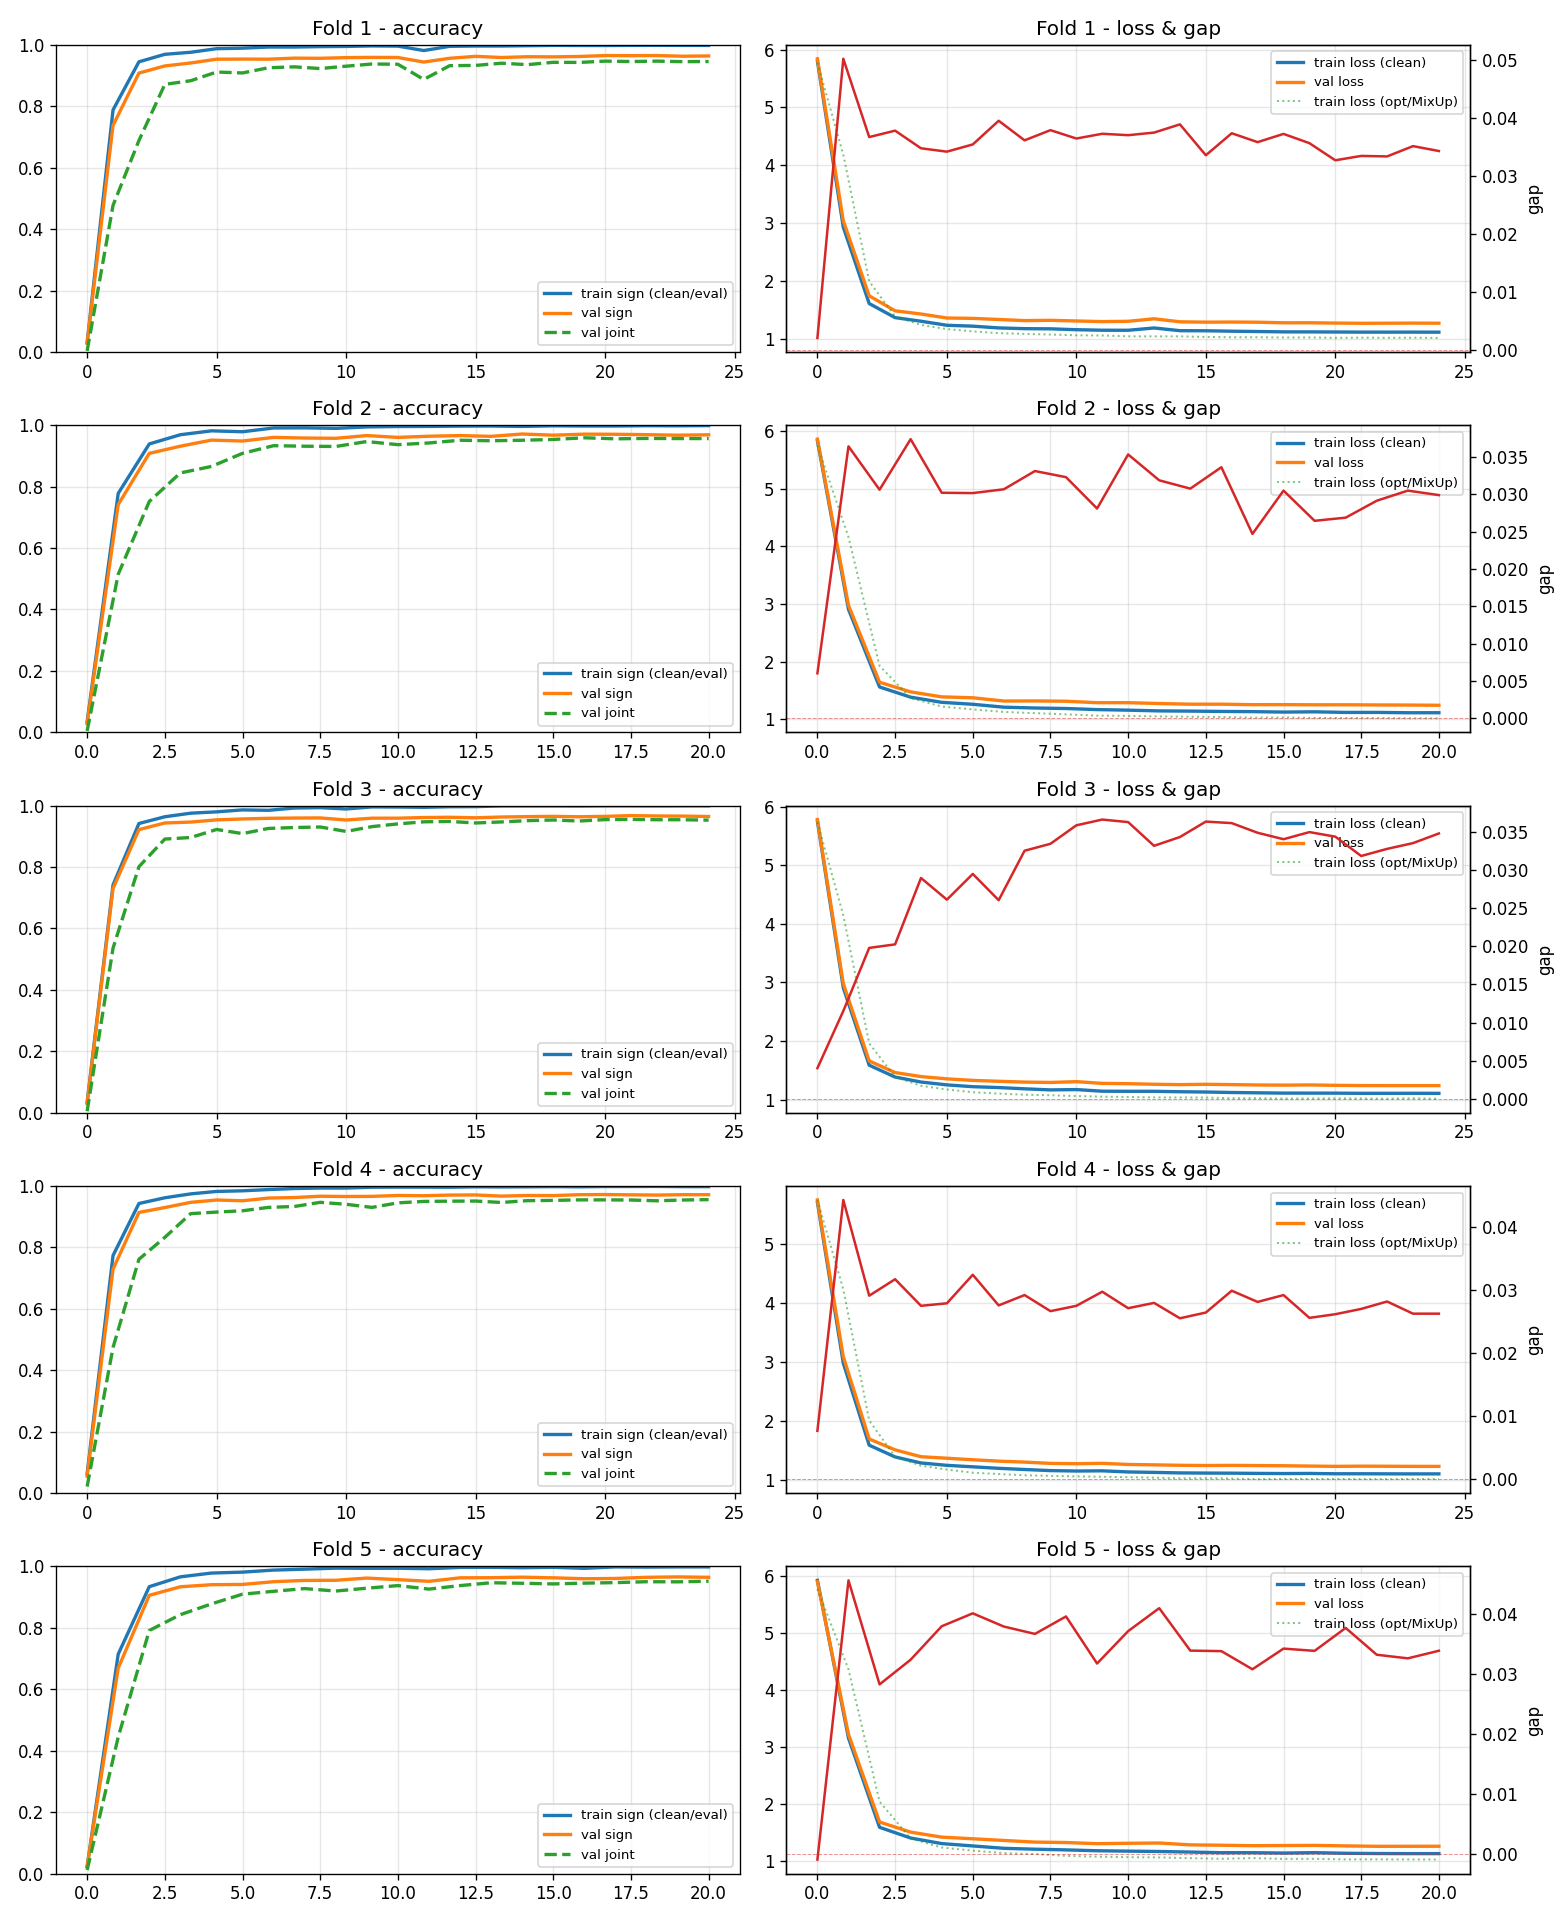

In [9]:
from IPython.display import Image as IPImage, display
fig, axes = plt.subplots(K_FOLDS, 2, figsize=(13, 3.2*K_FOLDS))
if K_FOLDS == 1: axes = np.array([axes])
for f, h in enumerate(fold_histories):
    ax = axes[f,0]
    ax.plot(h["tr_sign_acc"], label="train sign (clean/eval)", lw=2)
    ax.plot(h["va_sign_acc"], label="val sign", lw=2)
    ax.plot(h["va_joint_acc"], label="val joint", lw=2, ls="--")
    ax.set_title(f"Fold {f+1} - accuracy"); ax.set_ylim(0,1); ax.grid(alpha=.3); ax.legend(fontsize=8)
    ax2 = axes[f,1]
    ax2.plot(h["tr_loss"], label="train loss (clean)", lw=2)
    ax2.plot(h["va_loss"], label="val loss", lw=2)
    if "opt_loss" in h:
        ax2.plot(h["opt_loss"], label="train loss (opt/MixUp)", lw=1.2, ls=":", alpha=.6)
    ax2b = ax2.twinx(); ax2b.plot(h["gap"], color="C3", lw=1.5, label="gap (clean train - val)")
    ax2b.set_ylabel("gap"); ax2b.axhline(0, color="C3", lw=.6, ls="--", alpha=.5)
    ax2.set_title(f"Fold {f+1} - loss & gap"); ax2.grid(alpha=.3); ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.savefig("results/training_curves.png", dpi=120); plt.close()
print("Saved -> results/training_curves.png")
display(IPImage("results/training_curves.png"))


## Overfitting check

In [10]:
print("="*64); print("  OVERFITTING CHECK  (gap = clean_train_acc - val_acc)"); print("="*64)
for f, h in enumerate(fold_histories):
    max_gap   = max(h["gap"])
    best_ep   = int(np.argmax(h["va_sign_f1"])) + 1
    val_at_end_drop = h["va_sign_f1"][best_ep-1] - h["va_sign_f1"][-1]
    peak_train = max(h["tr_sign_acc"])
    print(f"Fold {f+1}: peak clean-train sign acc={peak_train:.3f} | max gap={max_gap:+.3f} | "
          f"best epoch={best_ep} | val-F1 drop after peak={val_at_end_drop:+.3f}")
print("\nHow to read the gap now that train is measured the SAME way as val (eval mode, clean images):")
print("  gap ~ 0.00         -> excellent generalisation (train ~= val)")
print("  gap 0.00 .. 0.05   -> healthy")
print("  gap > ~0.10        -> starting to overfit (you'd also see val F1 fall after its peak)")
print("A NEGATIVE gap is now unusual and just means the (small) clean-train subset happened to be")
print("slightly harder than the val split; with regularisation this is fine.")


  OVERFITTING CHECK  (gap = clean_train_acc - val_acc)
Fold 1: peak clean-train sign acc=0.998 | max gap=+0.050 | best epoch=23 | val-F1 drop after peak=+0.001
Fold 2: peak clean-train sign acc=0.999 | max gap=+0.037 | best epoch=15 | val-F1 drop after peak=+0.005
Fold 3: peak clean-train sign acc=0.999 | max gap=+0.037 | best epoch=22 | val-F1 drop after peak=+0.005
Fold 4: peak clean-train sign acc=0.999 | max gap=+0.044 | best epoch=20 | val-F1 drop after peak=+0.003
Fold 5: peak clean-train sign acc=0.998 | max gap=+0.046 | best epoch=15 | val-F1 drop after peak=+0.005

How to read the gap now that train is measured the SAME way as val (eval mode, clean images):
  gap ~ 0.00         -> excellent generalisation (train ~= val)
  gap 0.00 .. 0.05   -> healthy
  gap > ~0.10        -> starting to overfit (you'd also see val F1 fall after its peak)
A NEGATIVE gap is now unusual and just means the (small) clean-train subset happened to be
slightly harder than the val split; with regularis

## Ensemble inference helpers (soft & hard voting)

In [11]:
@torch.no_grad()
def cvv_inference(models, loader):
    out = defaultdict(list)
    for m in models: m.eval()
    for imgs, sl, dl in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        sp_k, dp_k = [], []
        for m in models:
            with autocast("cuda", enabled=USE_AMP):
                so, do = m(imgs)
            sp_k.append(F.softmax(so.float(),1).cpu()); dp_k.append(F.softmax(do.float(),1).cpu())
        sp_k, dp_k = torch.stack(sp_k), torch.stack(dp_k)
        out["sign_soft"].append(sp_k.mean(0).argmax(1).numpy())
        out["dir_soft"].append(dp_k.mean(0).argmax(1).numpy())
        out["sign_hard"].append(torch.mode(sp_k.argmax(2),0).values.numpy())
        out["dir_hard"].append(torch.mode(dp_k.argmax(2),0).values.numpy())
        out["sign_true"].append(sl.numpy()); out["dir_true"].append(dl.numpy())
    return {k: np.concatenate(v) for k, v in out.items()}

def clf_metrics(pred, true, tag):
    r = dict(tag=tag,
             accuracy=accuracy_score(true,pred),
             balanced_accuracy=balanced_accuracy_score(true,pred),
             precision=precision_score(true,pred,average="macro",zero_division=0),
             recall=recall_score(true,pred,average="macro",zero_division=0),
             f1=f1_score(true,pred,average="macro",zero_division=0))
    print(f"  {tag:14s} acc={r['accuracy']:.4f} bacc={r['balanced_accuracy']:.4f} f1={r['f1']:.4f}")
    return r
print("Inference helpers ready.")


Inference helpers ready.


## Held-out test evaluation (per-fold + ensemble)

In [12]:
test_ds     = DualHeadDataset(test_samples_raw, val_tfm, train=False)
test_loader = DataLoader(test_ds, batch_size=CLF_BATCH, shuffle=False, num_workers=2, pin_memory=True)

sign_rows, dir_rows, joint_rows = [], [], []
print("Per-fold (MSLOT):")
for f, m in enumerate(cvv_models):
    m.eval(); sp, dp, st, dt = [], [], [], []
    with torch.no_grad():
        for imgs, sl, dl in test_loader:
            with autocast("cuda", enabled=USE_AMP):
                so, do = m(imgs.to(DEVICE))
            sp += so.argmax(1).cpu().tolist(); dp += do.argmax(1).cpu().tolist()
            st += sl.tolist(); dt += dl.tolist()
    sp, dp, st, dt = map(np.array, (sp, dp, st, dt))
    sign_rows.append(clf_metrics(sp, st, f"MSLOT{f} sign"))
    dir_rows .append(clf_metrics(dp, dt, f"MSLOT{f} dir"))
    joint_rows.append({"tag": f"MSLOT{f}", "joint_accuracy": float(((sp==st)&(dp==dt)).mean())})

print("\nEnsemble (CVV):")
cvv = cvv_inference(cvv_models, test_loader)
sign_rows.append(clf_metrics(cvv["sign_soft"], cvv["sign_true"], "CVV-SV sign"))
sign_rows.append(clf_metrics(cvv["sign_hard"], cvv["sign_true"], "CVV-HV sign"))
dir_rows .append(clf_metrics(cvv["dir_soft"],  cvv["dir_true"],  "CVV-SV dir"))
dir_rows .append(clf_metrics(cvv["dir_hard"],  cvv["dir_true"],  "CVV-HV dir"))
joint_rows.append({"tag":"CVV-SV","joint_accuracy":float(((cvv["sign_soft"]==cvv["sign_true"])&(cvv["dir_soft"]==cvv["dir_true"])).mean())})
joint_rows.append({"tag":"CVV-HV","joint_accuracy":float(((cvv["sign_hard"]==cvv["sign_true"])&(cvv["dir_hard"]==cvv["dir_true"])).mean())})

df_sign, df_dir, df_joint = pd.DataFrame(sign_rows), pd.DataFrame(dir_rows), pd.DataFrame(joint_rows)
print("\n=== JOINT ACCURACY ==="); print(df_joint.to_string(index=False))
for d, n in [(df_sign,"sign"),(df_dir,"dir"),(df_joint,"joint")]:
    d.to_csv(f"results/{n}_metrics.csv", index=False)
print("\nDirection report (CVV-SV):")
print(classification_report(cvv["dir_true"], cvv["dir_soft"], target_names=DIRECTIONS, digits=4, zero_division=0))


Per-fold (MSLOT):
  MSLOT0 sign    acc=0.9719 bacc=0.9546 f1=0.9475
  MSLOT0 dir     acc=0.9749 bacc=0.9605 f1=0.9390
  MSLOT1 sign    acc=0.9688 bacc=0.9432 f1=0.9337
  MSLOT1 dir     acc=0.9688 bacc=0.9606 f1=0.9263
  MSLOT2 sign    acc=0.9658 bacc=0.9440 f1=0.9364
  MSLOT2 dir     acc=0.9719 bacc=0.9632 f1=0.9364
  MSLOT3 sign    acc=0.9605 bacc=0.9266 f1=0.9139
  MSLOT3 dir     acc=0.9719 bacc=0.9557 f1=0.9323
  MSLOT4 sign    acc=0.9650 bacc=0.9391 f1=0.9183
  MSLOT4 dir     acc=0.9734 bacc=0.9672 f1=0.9361

Ensemble (CVV):
  CVV-SV sign    acc=0.9742 bacc=0.9608 f1=0.9518
  CVV-HV sign    acc=0.9734 bacc=0.9544 f1=0.9480
  CVV-SV dir     acc=0.9749 bacc=0.9648 f1=0.9396
  CVV-HV dir     acc=0.9757 bacc=0.9656 f1=0.9419

=== JOINT ACCURACY ===
   tag  joint_accuracy
MSLOT0        0.952128
MSLOT1        0.942249
MSLOT2        0.943009
MSLOT3        0.938450
MSLOT4        0.943769
CVV-SV        0.952888
CVV-HV        0.953647

Direction report (CVV-SV):
              precision    re

## Direction confusion matrix & worst sign classes

In [13]:
cm = confusion_matrix(cvv["dir_true"], cvv["dir_soft"], labels=list(range(NUM_DIRECTIONS)))
cmn = cm.astype(float)/cm.sum(1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(1,2, figsize=(11,4.2))
for a, mat, ttl, fm in [(ax[0],cm,"Direction CM","d"),(ax[1],cmn,"Direction CM (norm)",".2f")]:
    im=a.imshow(mat,cmap="Blues"); a.set_xticks(range(3)); a.set_yticks(range(3))
    a.set_xticklabels(DIRECTIONS); a.set_yticklabels(DIRECTIONS); a.set_xlabel("Pred"); a.set_ylabel("True"); a.set_title(ttl)
    for i in range(3):
        for j in range(3): a.text(j,i,format(mat[i,j],fm),ha="center",va="center",color="white" if mat[i,j]>mat.max()*0.5 else "black")
plt.tight_layout(); plt.savefig("results/direction_confusion_matrix.png", dpi=120); plt.close()

prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(cvv["sign_true"], cvv["sign_soft"], average=None, zero_division=0)
worst = np.argsort(f1_c)[:30]
plt.figure(figsize=(12,5)); plt.bar(range(len(worst)), f1_c[worst])
plt.xticks(range(len(worst)), [CLASS_NAMES[i] for i in worst], rotation=90)
plt.title("CVV-SV: 30 worst sign classes by F1"); plt.ylabel("F1"); plt.tight_layout()
plt.savefig("results/worst_sign_f1.png", dpi=120); plt.close()

mask = cvv["sign_true"] != cvv["sign_soft"]
pairs = Counter(zip(cvv["sign_true"][mask], cvv["sign_soft"][mask]))
print("Top sign confusion pairs (CVV-SV):")
for (a,b),c in pairs.most_common(15): print(f"  {CLASS_NAMES[a]:<7} -> {CLASS_NAMES[b]:<7} : {c}")
print("Saved confusion-matrix and worst-F1 plots to results/.")


Top sign confusion pairs (CVV-SV):
  d54     -> d55     : 3
  v30     -> v31     : 2
  d55     -> d54     : 2
  n33     -> s21     : 2
  d45     -> f32     : 1
  m17     -> s29     : 1
  d36     -> d37     : 1
  v6      -> s27     : 1
  g37     -> g36     : 1
  g35     -> g1      : 1
  w24     -> o50     : 1
  g1      -> g35     : 1
  d58     -> n29     : 1
  q3      -> q1      : 1
  v13     -> n18     : 1
Saved confusion-matrix and worst-F1 plots to results/.


## Full 162-class sign confusion matrix

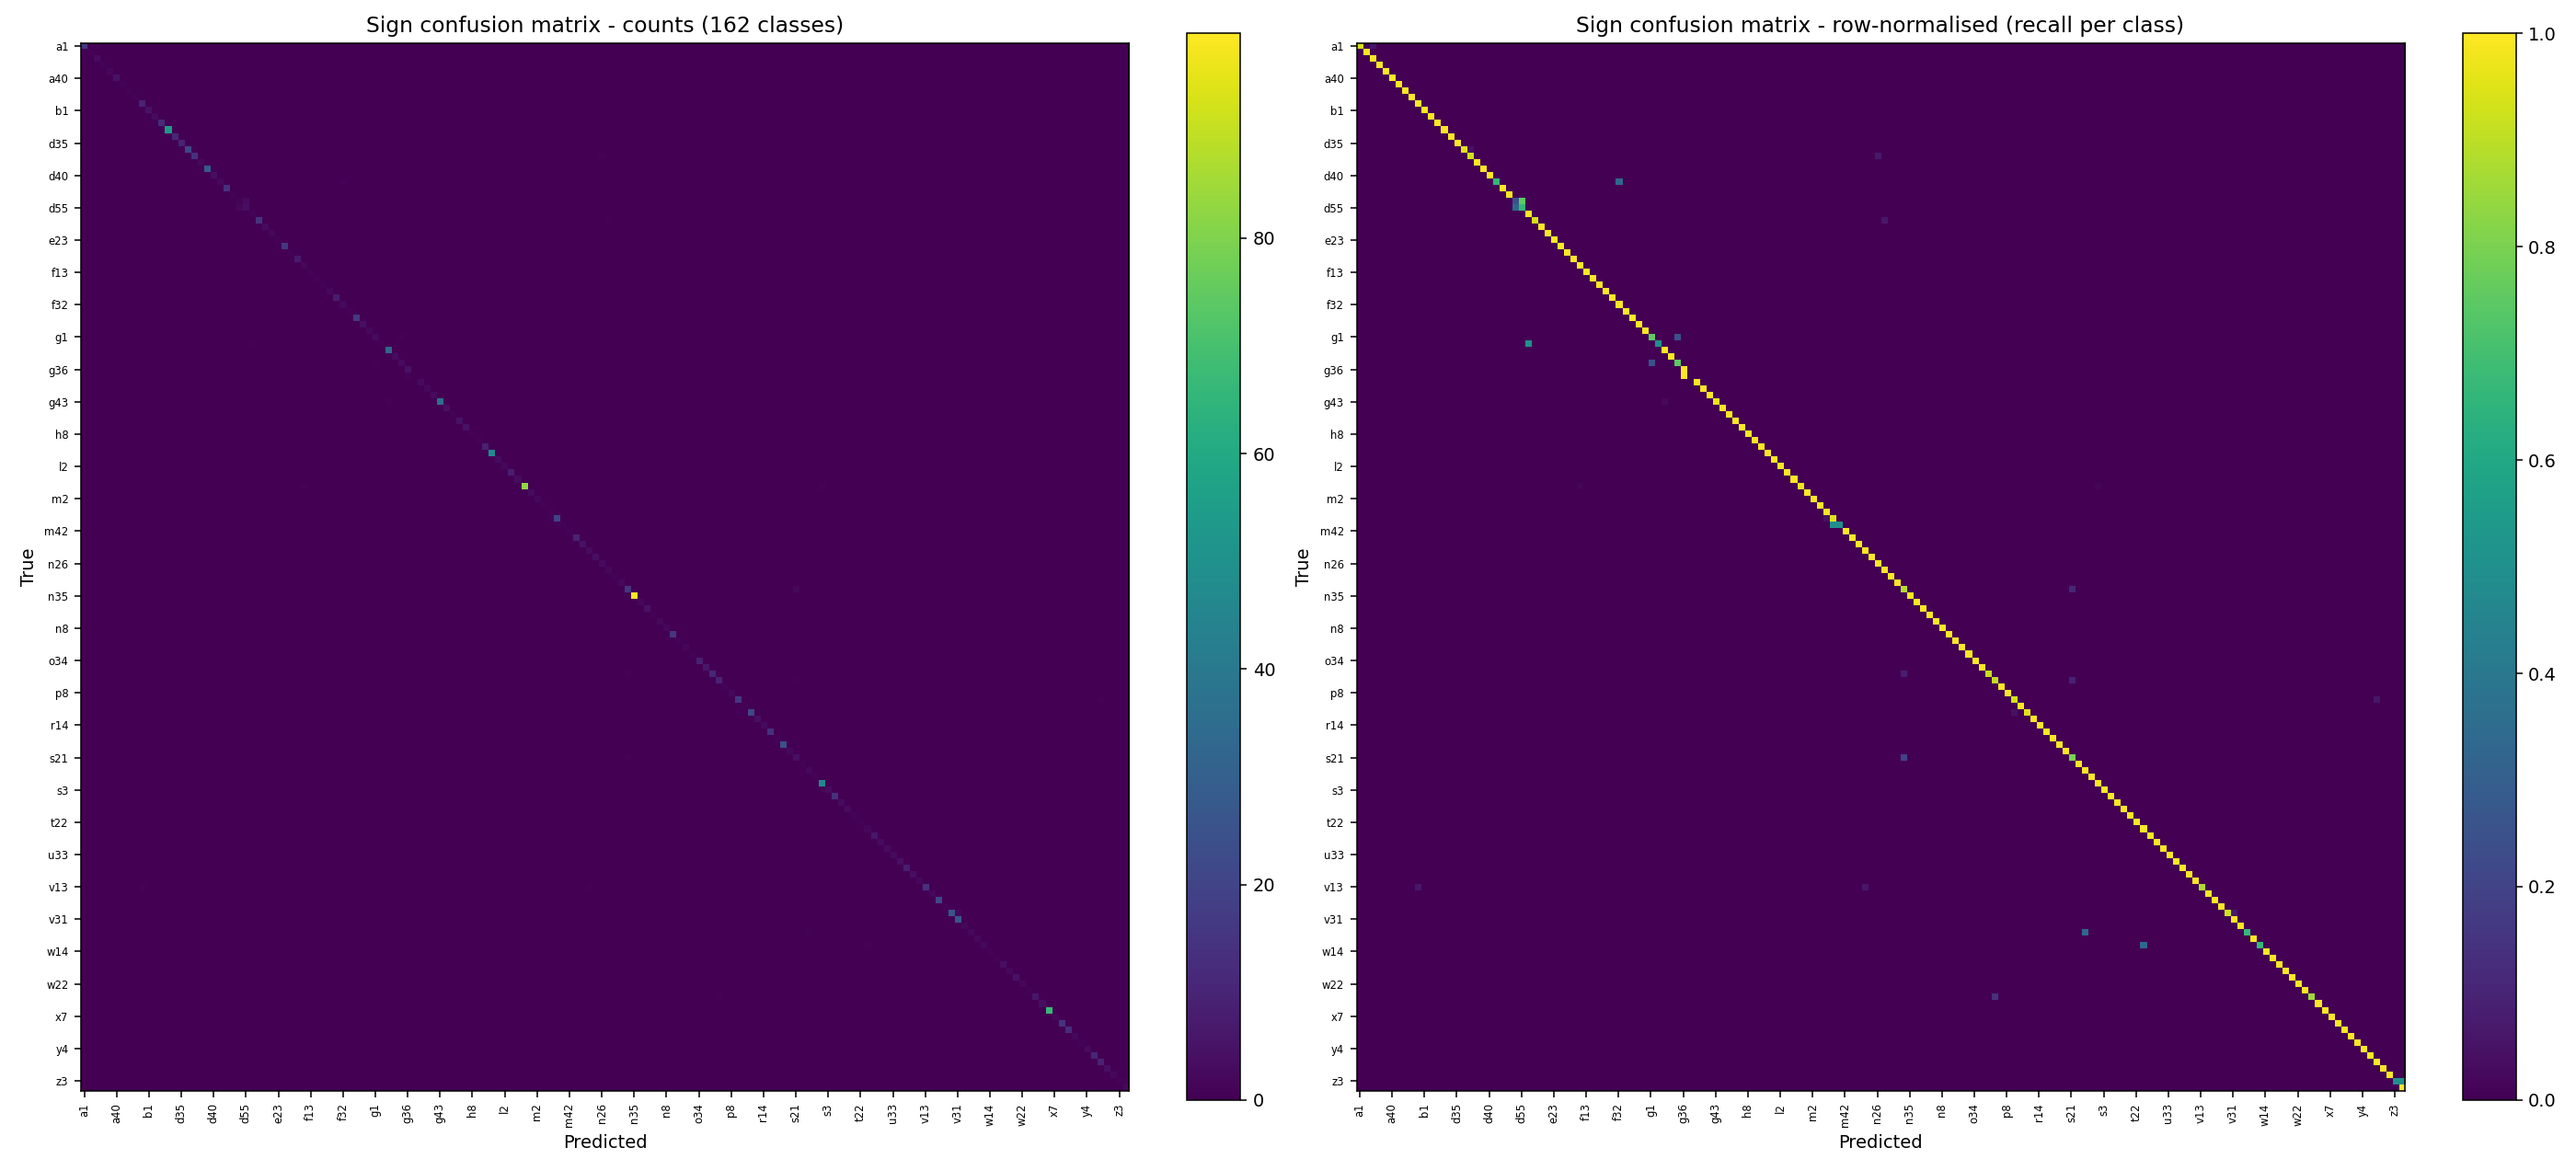

Sign CM diagonal (mean per-class recall): 0.9608
Classes with recall < 0.50      : 2 / 162
Perfect classes (recall = 1.00) : 135 / 162
Saved -> results/sign_confusion_matrix.png


In [14]:
from IPython.display import Image as IPImage, display

sign_cm      = confusion_matrix(cvv["sign_true"], cvv["sign_soft"], labels=list(range(NUM_CLASSES)))
sign_cm_norm = sign_cm.astype(float) / sign_cm.sum(1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))
im0 = ax[0].imshow(sign_cm, cmap="viridis")
ax[0].set_title(f"Sign confusion matrix - counts ({NUM_CLASSES} classes)")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
fig.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(sign_cm_norm, cmap="viridis", vmin=0, vmax=1)
ax[1].set_title("Sign confusion matrix - row-normalised (recall per class)")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")
fig.colorbar(im1, ax=ax[1], fraction=0.046)
for a in ax:
    a.set_xticks(range(0, NUM_CLASSES, 5)); a.set_yticks(range(0, NUM_CLASSES, 5))
    a.set_xticklabels([CLASS_NAMES[i] for i in range(0, NUM_CLASSES, 5)], rotation=90, fontsize=6)
    a.set_yticklabels([CLASS_NAMES[i] for i in range(0, NUM_CLASSES, 5)], fontsize=6)
plt.tight_layout(); plt.savefig("results/sign_confusion_matrix.png", dpi=140); plt.close()
display(IPImage("results/sign_confusion_matrix.png"))

diag_recall = np.diag(sign_cm_norm)
print(f"Sign CM diagonal (mean per-class recall): {diag_recall.mean():.4f}")
print(f"Classes with recall < 0.50      : {int((diag_recall < 0.5).sum())} / {NUM_CLASSES}")
print(f"Perfect classes (recall = 1.00) : {int((diag_recall >= 0.999).sum())} / {NUM_CLASSES}")
print("Saved -> results/sign_confusion_matrix.png")


## Save models, label maps & config

In [25]:
for f, m in enumerate(cvv_models):
    torch.save(m.state_dict(), f"cvv_models/fold_{f}_final.pt")
with open("cvv_models/label_maps.json","w") as fp:
    json.dump({"sign_classes":CLASS_NAMES,"directions":DIRECTIONS,"img_size":IMG_SIZE,
               "backbone":CONVNEXT_BACKBONE,"num_classes":NUM_CLASSES,"num_directions":NUM_DIRECTIONS}, fp, indent=2)
with open("results/config.json","w") as fp:
    json.dump({"seed":SEED,"img_size":IMG_SIZE,"backbone":CONVNEXT_BACKBONE,"k_folds":K_FOLDS,
               "epochs":CLF_EPOCHS,"batch":CLF_BATCH,"lr_backbone":LR_BACKBONE,"lr_head":LR_HEAD,
               "weight_decay":WEIGHT_DECAY,"drop_path":DROP_PATH_RATE,"head_dropout":HEAD_DROPOUT,
               "dir_loss_weight":DIR_LOSS_WEIGHT,"use_mixup":USE_MIXUP,"mixup_alpha":MIXUP_ALPHA}, fp, indent=2)
print("Saved 5 fold models + label_maps.json + config.json")


Saved 5 fold models + label_maps.json + config.json


## Interactive inference — upload an image, get sign + direction

`predict_pil` runs one image through the 5-model soft-vote ensemble using the same letterbox `val_tfm` as training, so there is no train/serve skew.

In [26]:
def get_inference_models():
    if "cvv_models" in globals() and len(cvv_models) > 0:
        return cvv_models
    ms = []
    for i in range(K_FOLDS):
        p = f"cvv_models/fold_{i}_final.pt"
        if os.path.exists(p):
            m = build_model(pretrained=False).to(DEVICE)
            m.load_state_dict(torch.load(p, map_location=DEVICE)); m.eval(); ms.append(m)
    if not ms: raise RuntimeError("No models found. Train first or place fold_*_final.pt in cvv_models/.")
    return ms

@torch.no_grad()
def predict_pil(img, models=None, topk=3):
    models = models or get_inference_models()
    x = val_tfm(img.convert("RGB")).unsqueeze(0).to(DEVICE)
    sp, dp = [], []
    for m in models:
        m.eval()
        with autocast("cuda", enabled=USE_AMP):
            so, do = m(x)
        sp.append(F.softmax(so.float(),1).cpu()); dp.append(F.softmax(do.float(),1).cpu())
    sp = torch.stack(sp).mean(0)[0]; dp = torch.stack(dp).mean(0)[0]
    si, di = int(sp.argmax()), int(dp.argmax())
    tk = torch.topk(sp, min(topk, len(sp)))
    return {"sign":IDX_TO_CLASS[si], "sign_conf":float(sp[si]),
            "direction":IDX_TO_DIR[di], "dir_conf":float(dp[di]),
            "top_signs":[(IDX_TO_CLASS[int(i)], float(p)) for p,i in zip(tk.values, tk.indices)]}

def predict_image(path, models=None, topk=3):
    return predict_pil(Image.open(path), models=models, topk=topk)

print("Demo on test samples:")
for path, st, dt in test_samples_raw[:5]:
    r = predict_image(path)
    print(f"  true=({IDX_TO_CLASS[st]:<6},{IDX_TO_DIR[dt]:<5})  "
          f"pred=({r['sign']:<6},{r['direction']:<5})  conf=(sign {r['sign_conf']:.2f}, dir {r['dir_conf']:.2f})")


Demo on test samples:
  true=(i9    ,right)  pred=(i9    ,right)  conf=(sign 0.59, dir 0.79)
  true=(d21   ,dual )  pred=(d21   ,dual )  conf=(sign 0.91, dir 0.81)
  true=(i10   ,right)  pred=(i10   ,right)  conf=(sign 0.94, dir 0.91)
  true=(x1    ,dual )  pred=(x1    ,dual )  conf=(sign 0.92, dir 0.83)
  true=(n18   ,dual )  pred=(n18   ,dual )  conf=(sign 0.91, dir 0.83)


## Per-class probe — one image from every class

Probing 162 / 162 classes (one image each, test-set first)...

One-shot-per-class  ->  sign acc = 0.9568 | direction acc = 0.9630



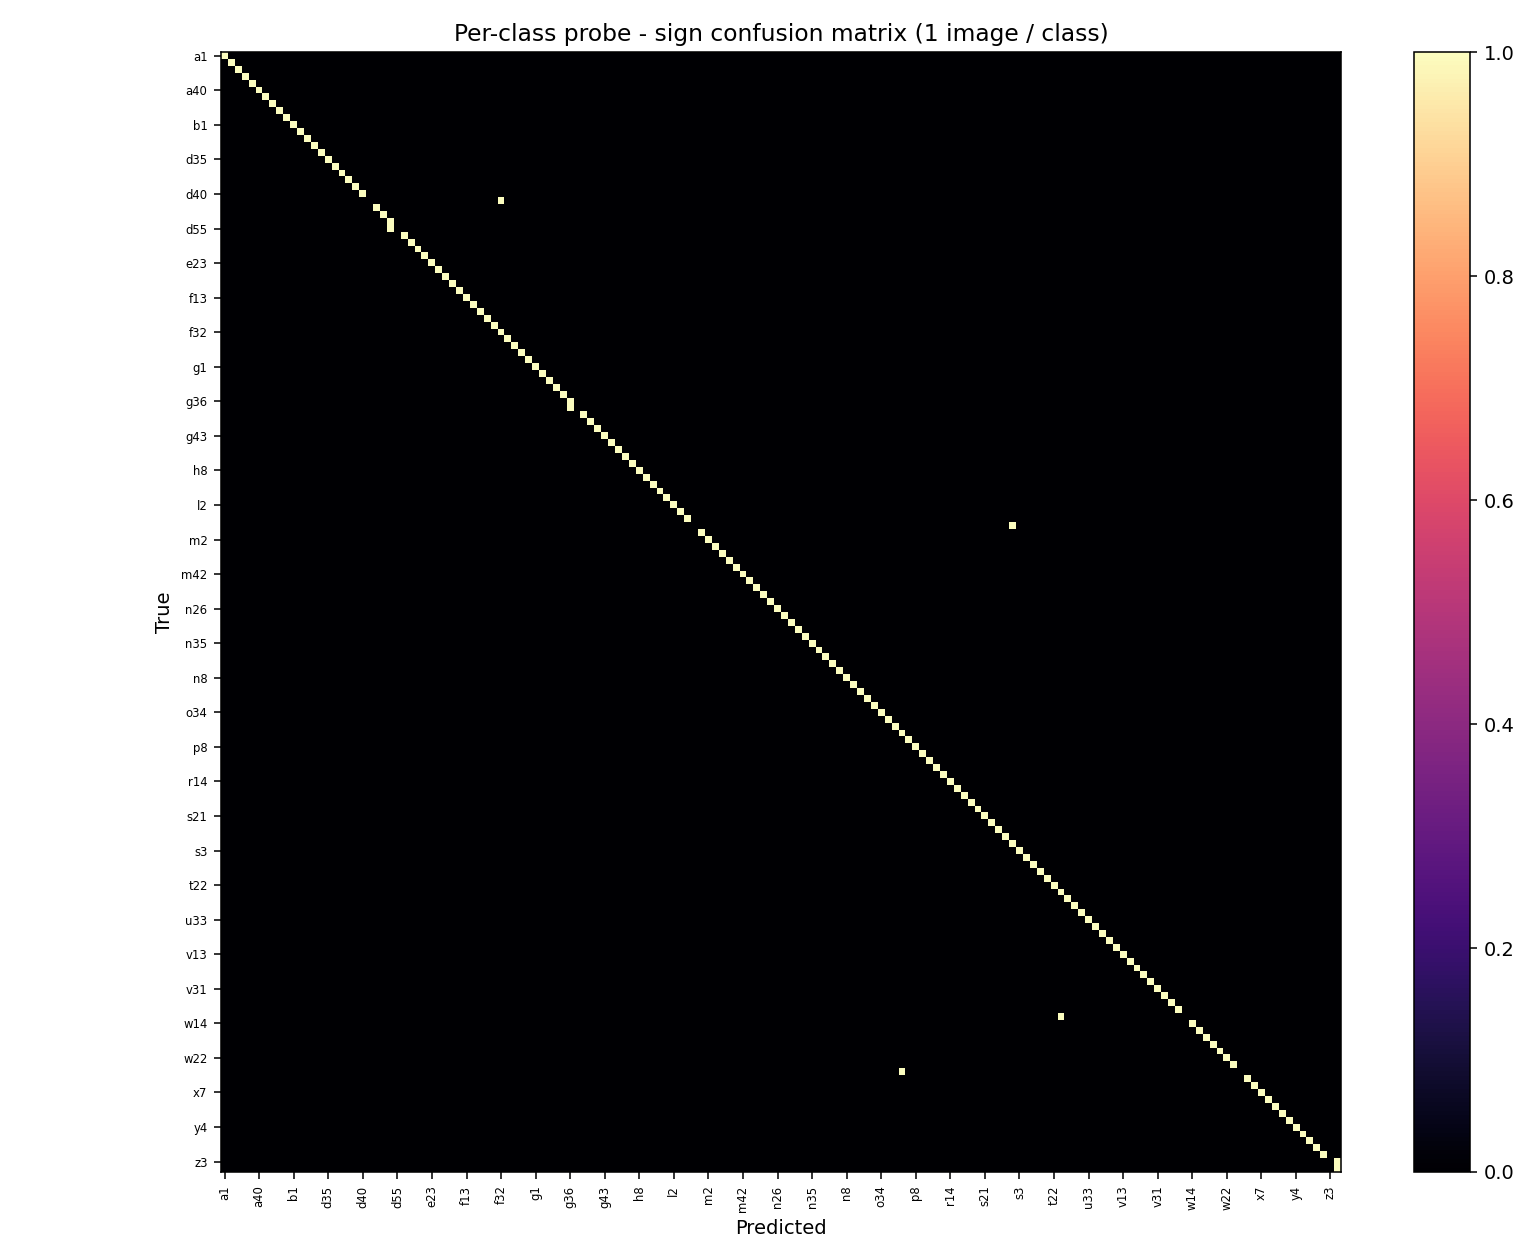

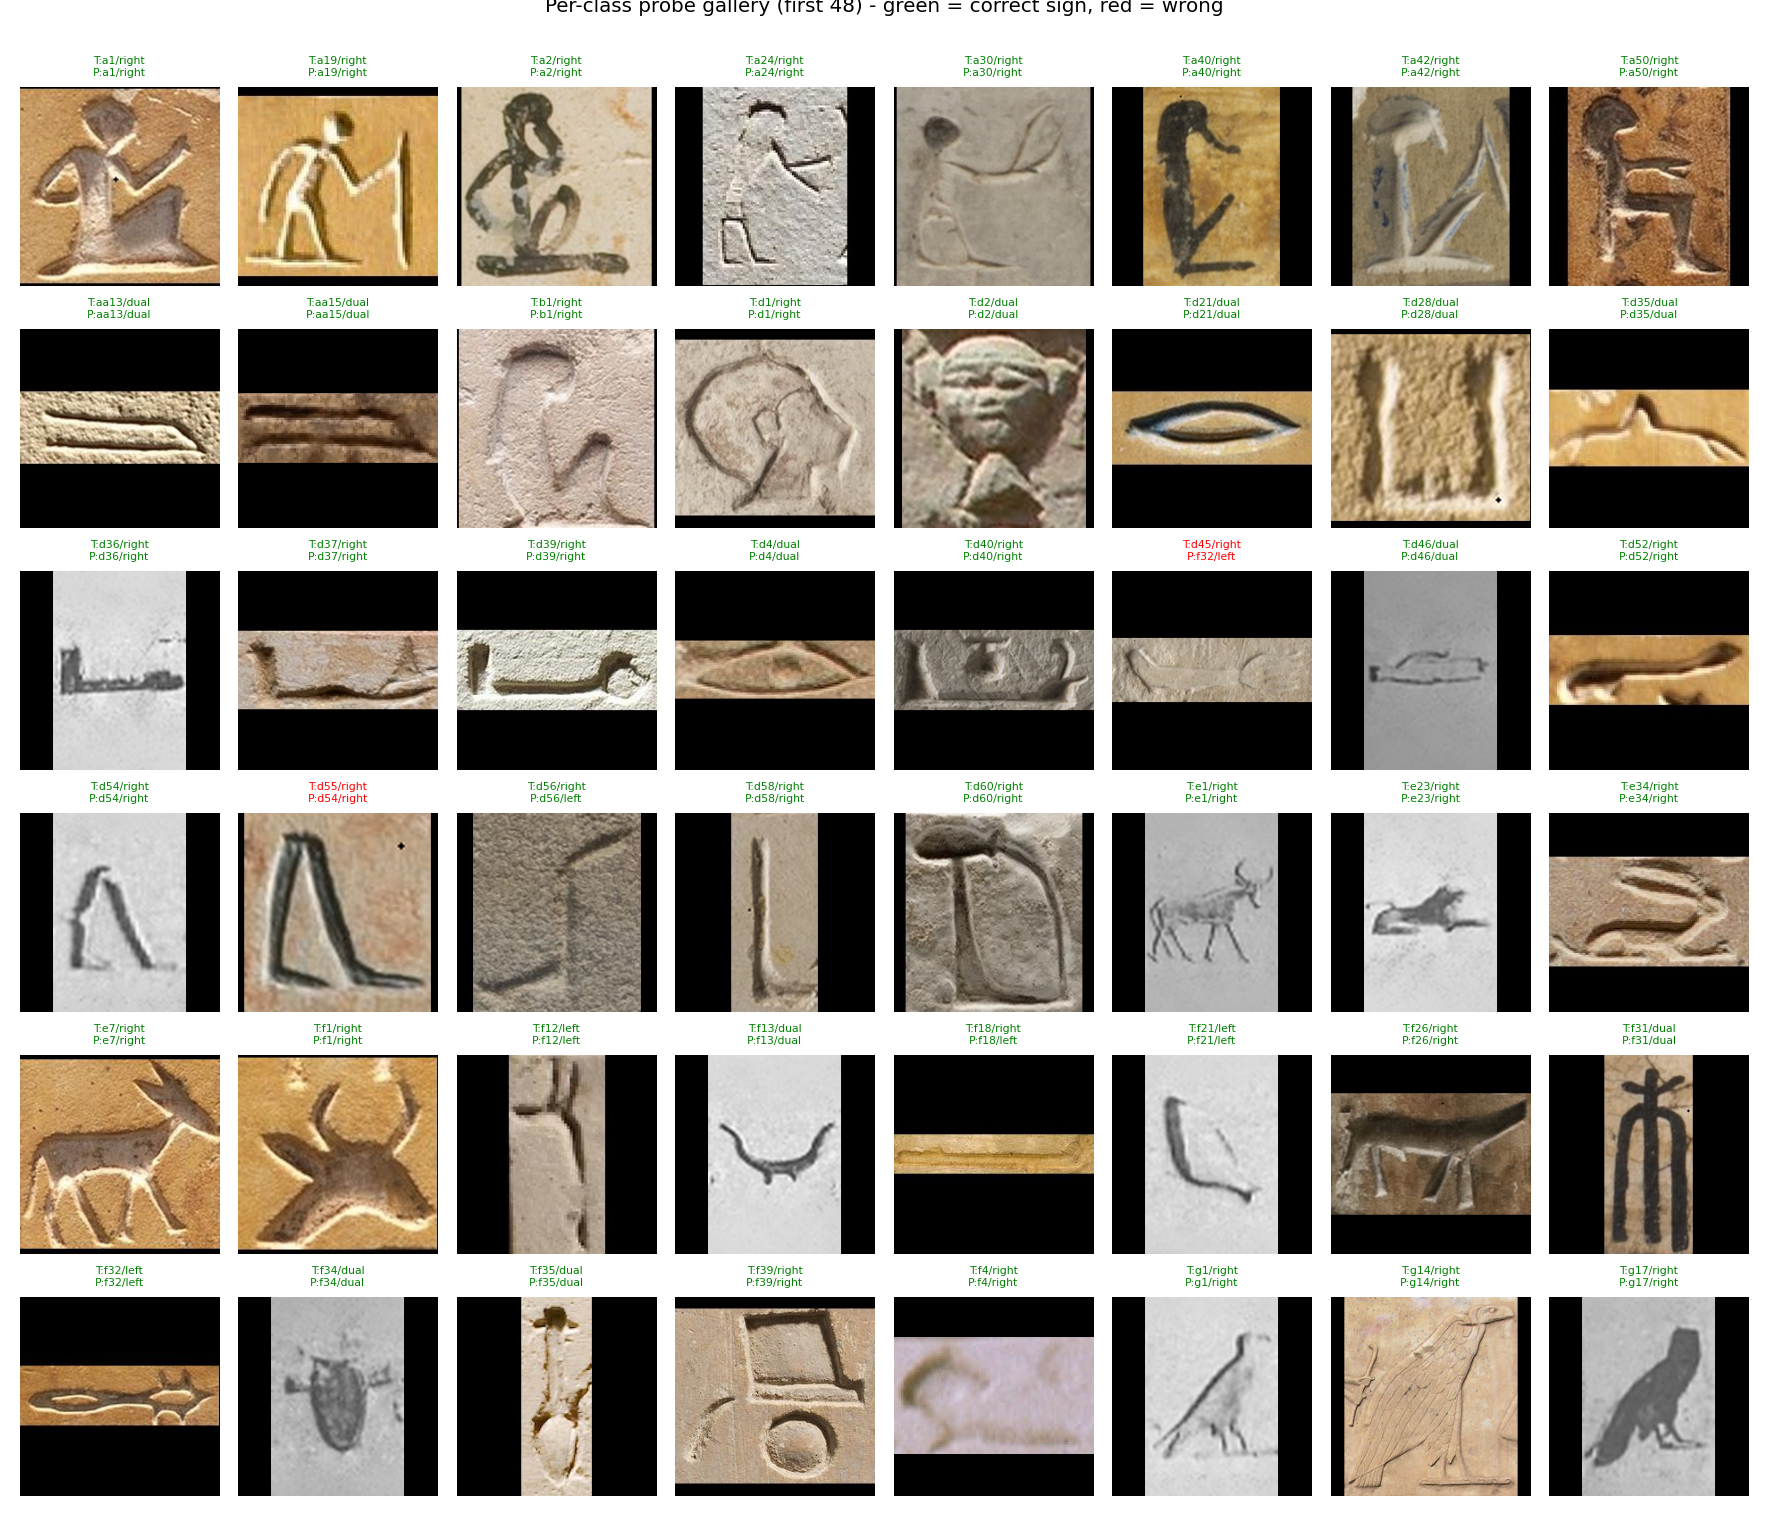

Misclassified classes on the probe (7):
  d45     -> f32
  d55     -> d54
  g37     -> g36
  m17     -> s29
  w11     -> t28
  w24     -> o50
  z3      -> z4


In [27]:
import math
from IPython.display import Image as IPImage, display

by_class_test = defaultdict(list)
for p, s, d in test_samples_raw:
    by_class_test[s].append((p, s, d))
by_class_all = defaultdict(list)
for p, s, d in df_to_samples(samples_df):
    by_class_all[s].append((p, s, d))

probe_rng = random.Random(SEED)
probe_samples = []
for c in range(NUM_CLASSES):
    pool = by_class_test.get(c) or by_class_all.get(c) or []
    if pool:
        probe_samples.append(probe_rng.choice(pool))
print(f"Probing {len(probe_samples)} / {NUM_CLASSES} classes (one image each, test-set first)...")

models = get_inference_models()
probe_true_sign, probe_pred_sign = [], []
probe_true_dir,  probe_pred_dir  = [], []
records = []
for p, s, d in probe_samples:
    try:    img = Image.open(p).convert("RGB")
    except Exception: continue
    r = predict_pil(img, models=models)
    ps  = CLASS_TO_IDX[r["sign"]]
    pdir = DIR_TO_IDX[r["direction"]]
    probe_true_sign.append(s); probe_pred_sign.append(ps)
    probe_true_dir.append(d);  probe_pred_dir.append(pdir)
    records.append((p, s, d, ps, pdir, r["sign_conf"], r["dir_conf"]))

probe_true_sign = np.array(probe_true_sign); probe_pred_sign = np.array(probe_pred_sign)
probe_true_dir  = np.array(probe_true_dir);  probe_pred_dir  = np.array(probe_pred_dir)

sign_top1 = float((probe_true_sign == probe_pred_sign).mean())
dir_top1  = float((probe_true_dir  == probe_pred_dir ).mean())
print(f"\nOne-shot-per-class  ->  sign acc = {sign_top1:.4f} | direction acc = {dir_top1:.4f}\n")

probe_cm = confusion_matrix(probe_true_sign, probe_pred_sign, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(11, 9)); plt.imshow(probe_cm, cmap="magma")
plt.title("Per-class probe - sign confusion matrix (1 image / class)")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.colorbar(fraction=0.046)
plt.xticks(range(0, NUM_CLASSES, 5), [CLASS_NAMES[i] for i in range(0, NUM_CLASSES, 5)], rotation=90, fontsize=6)
plt.yticks(range(0, NUM_CLASSES, 5), [CLASS_NAMES[i] for i in range(0, NUM_CLASSES, 5)], fontsize=6)
plt.tight_layout(); plt.savefig("results/perclass_probe_confusion.png", dpi=140); plt.close()
display(IPImage("results/perclass_probe_confusion.png"))

N = min(48, len(records)); cols = 8; rows = math.ceil(N / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*1.7, rows*1.95))
axes = np.array(axes).reshape(-1)
for k in range(rows*cols):
    a = axes[k]; a.axis("off")
    if k < N:
        p, s, d, ps, pdir, sc, dc = records[k]
        try: a.imshow(Image.open(p).convert("RGB"))
        except Exception: pass
        ok = (s == ps)
        a.set_title(f"T:{IDX_TO_CLASS[s]}/{IDX_TO_DIR[d]}\nP:{IDX_TO_CLASS[ps]}/{IDX_TO_DIR[pdir]}",
                    fontsize=6, color=("green" if ok else "red"))
plt.suptitle(f"Per-class probe gallery (first {N}) - green = correct sign, red = wrong", y=1.002, fontsize=11)
plt.tight_layout(); plt.savefig("results/perclass_probe_gallery.png", dpi=130); plt.close()
display(IPImage("results/perclass_probe_gallery.png"))

wrong = [(IDX_TO_CLASS[s], IDX_TO_CLASS[ps]) for (_, s, _, ps, _, _, _) in records if s != ps]
print(f"Misclassified classes on the probe ({len(wrong)}):")
for t, pcls in wrong: print(f"  {t:<7} -> {pcls}")


## Zip outputs for download

In [31]:
import shutil, os, time
from pathlib import Path

# امسح كل الـ runs القديمة
for old in Path("/kaggle/working").glob("cvv_sign_dir_final_*"):
    if old.is_dir():
        shutil.rmtree(old)
    elif old.suffix == ".zip":
        old.unlink()

RUN = time.strftime("cvv_sign_dir_final_%Y%m%d_%H%M")
SAVE = f"/kaggle/working/{RUN}"
os.makedirs(SAVE, exist_ok=True)

for d in ["cvv_models", "results"]:
    for f in Path(d).glob("*"):
        shutil.copy2(str(f), SAVE)

shutil.make_archive(f"/kaggle/working/{RUN}", "zip", SAVE)

# امسح الـ folder، خلي بس الـ zip
shutil.rmtree(SAVE)

print("Created:", f"/kaggle/working/{RUN}.zip")

Created: /kaggle/working/cvv_sign_dir_final_20260603_0016.zip


## Upload widget

In [32]:
from IPython.display import display, clear_output, HTML
try:
    import ipywidgets as widgets

    uploader = widgets.FileUpload(accept="image/*", multiple=False, description="Upload")
    run_btn  = widgets.Button(description="Predict", button_style="success", icon="search")
    out_box  = widgets.Output()

    def _read_upload(up):
        if not up.value: return None
        v = up.value
        item = (list(v.values())[0] if isinstance(v, dict) else v[0])
        content = item["content"]
        return Image.open(io.BytesIO(bytes(content))).convert("RGB")

    def _on_click(_):
        with out_box:
            clear_output()
            img = _read_upload(uploader)
            if img is None:
                print("Please upload an image first."); return
            r = predict_pil(img)
            display(img.resize((180, 180)))
            top3 = "  ".join(f"{c}:{p*100:.1f}%" for c, p in r["top_signs"])
            display(HTML(
                "<div style='font-family:monospace;font-size:14px;line-height:1.6'>"
                f"<b>Sign</b>      : {r['sign']} ({r['sign_conf']*100:.1f}%)<br>"
                f"<b>Direction</b> : {r['direction']} ({r['dir_conf']*100:.1f}%)<br>"
                f"<b>Top-3 sign</b>: {top3}</div>"))

    run_btn.on_click(_on_click)
    display(widgets.VBox([widgets.HTML("<b>Upload a hieroglyph image, then press Predict (sign + direction)</b>"),
                          uploader, run_btn, out_box]))
except Exception as e:
    print("ipywidgets unavailable -> use predict_image('/path/to/image.png'). Reason:", e)


## Leakage check & source breakdown

MD5 identical-image check between train and test, then accuracy split by data source (main dataset vs synthetic *franken* images).

In [33]:
import hashlib

print(ann["source"].value_counts())
print("---")
print(ann["abs_path"].head(8).tolist())
print("="*50)

def md5(path, chunk=1<<16):
    h = hashlib.md5()
    try:
        with open(path, "rb") as f:
            for b in iter(lambda: f.read(chunk), b""):
                h.update(b)
        return h.hexdigest()
    except Exception:
        return None

train_hashes = {}
for p in trainval_df["abs_path"]:
    hsh = md5(p)
    if hsh: train_hashes.setdefault(hsh, []).append(p)

leak = 0
for p in test_df["abs_path"]:
    hsh = md5(p)
    if hsh and hsh in train_hashes:
        leak += 1

print(f"صور في التيست متطابقة تماماً مع صور في الترين: {leak} / {len(test_df)}")


source
main dataset    9284
franken         3871
Name: count, dtype: int64
---
['/kaggle/input/datasets/mennaalaarasslan/egyptian-hieroglyphic-text/Glyph2025/aa13/aa13_1.jpg', '/kaggle/input/datasets/mennaalaarasslan/egyptian-hieroglyphic-text/Glyph2025/aa13/aa13_10.png', '/kaggle/input/datasets/mennaalaarasslan/egyptian-hieroglyphic-text/Glyph2025/aa13/aa13_11.png', '/kaggle/input/datasets/mennaalaarasslan/egyptian-hieroglyphic-text/Glyph2025/aa13/aa13_12.png', '/kaggle/input/datasets/mennaalaarasslan/egyptian-hieroglyphic-text/Glyph2025/aa13/aa13_2.jpg', '/kaggle/input/datasets/mennaalaarasslan/egyptian-hieroglyphic-text/Glyph2025/aa13/aa13_3.jpg', '/kaggle/input/datasets/mennaalaarasslan/egyptian-hieroglyphic-text/Glyph2025/aa13/aa13_4.png', '/kaggle/input/datasets/mennaalaarasslan/egyptian-hieroglyphic-text/Glyph2025/aa13/aa13_5.png']
صور في التيست متطابقة تماماً مع صور في الترين: 0 / 1316


### Accuracy by data source

In [34]:
src_map  = dict(zip(ann["abs_path"], ann["source"]))
test_src = np.array([src_map.get(p) for p in test_df["abs_path"]])

ok_sign = (cvv["sign_soft"] == cvv["sign_true"])
ok_dir  = (cvv["dir_soft"]  == cvv["dir_true"])

print("source       N     sign_acc  dir_acc")
for s in ["main dataset", "franken"]:
    m = test_src == s
    if m.sum():
        print(f"{s:12s} {m.sum():4d}   {ok_sign[m].mean():.4f}   {ok_dir[m].mean():.4f}")


source       N     sign_acc  dir_acc
main dataset  941   0.9702   0.9702
franken       375   0.9840   0.9867


## Reading direction + reading-order sorting (add-on)

Batched classifier for in-memory segmentation crops, plus a pure-geometry LASC reading-order sorter. The trained classifier is not modified; these cells only consume its predictions.

In [35]:
def _to_pil(crop):
    """Accept a PIL image, a numpy array, or a file path -> RGB PIL image."""
    if isinstance(crop, Image.Image): return crop.convert("RGB")
    if isinstance(crop, np.ndarray):  return Image.fromarray(crop).convert("RGB")
    if isinstance(crop, str):         return Image.open(crop).convert("RGB")
    raise TypeError(f"Unsupported crop type: {type(crop)}")

@torch.no_grad()
def predict_crops(crops, models=None, voting="soft", batch_size=64):
    """Classify a list of sign crops with the CVV ensemble.

    Parameters
    ----------
    crops      : list of PIL.Image / np.ndarray / file paths.
    models     : trained DualHeadConvNeXt models (default: get_inference_models()).
    voting     : 'soft' (mean of probabilities, default) or 'hard' (modal vote).
    batch_size : forward-pass batch size.

    Returns
    -------
    list of dicts, one per crop:
        {gardiner, sign, direction, sign_conf, dir_conf, sign_idx, dir_idx}
    'direction' is the per-sign orientation: 'dual' | 'left' | 'right'.
    """
    models = models or get_inference_models()
    for m in models:
        m.eval()
    if not crops:
        return []

    X = torch.stack([val_tfm(_to_pil(c)) for c in crops])

    sign_chunks, dir_chunks = [], []
    for i in range(0, len(X), batch_size):
        xb = X[i:i + batch_size].to(DEVICE, non_blocking=True)
        sp_k, dp_k = [], []
        for m in models:
            with autocast("cuda", enabled=USE_AMP):
                so, do = m(xb)
            sp_k.append(F.softmax(so.float(), 1).cpu())
            dp_k.append(F.softmax(do.float(), 1).cpu())
        sp_k, dp_k = torch.stack(sp_k), torch.stack(dp_k)
        if voting == "soft":
            sign_chunks.append(sp_k.mean(0))
            dir_chunks.append(dp_k.mean(0))
        else:
            s_idx = sp_k.argmax(-1).mode(0).values
            d_idx = dp_k.argmax(-1).mode(0).values
            sign_chunks.append(F.one_hot(s_idx, NUM_CLASSES).float())
            dir_chunks.append(F.one_hot(d_idx, NUM_DIRECTIONS).float())

    sign_p = torch.cat(sign_chunks, 0)
    dir_p  = torch.cat(dir_chunks, 0)

    out = []
    for sp, dp in zip(sign_p, dir_p):
        si, di = int(sp.argmax()), int(dp.argmax())
        name = IDX_TO_CLASS[si]
        out.append({
            "gardiner":  name,
            "sign":      name,
            "direction": IDX_TO_DIR[di],
            "sign_conf": float(sp[si]),
            "dir_conf":  float(dp[di]),
            "sign_idx":  si,
            "dir_idx":   di,
        })
    return out

print("predict_crops() ready \u2713")


predict_crops() ready ✓


### Reading-direction voting + LASC reading-order sorter

In [36]:
import math

LEFT_, RIGHT_, DUAL_ = "left", "right", "dual"
LTR_,  RTL_          = "ltr",  "rtl"

def vote_direction(signs, tie_default=LTR_):
    """Vote a reading direction (ltr/rtl) from per-sign 'direction' fields."""
    left = right = 0
    for s in signs:
        d = s.get("direction")
        if   d == LEFT_:  left  += 1
        elif d == RIGHT_: right += 1

    if right > left:  return RTL_
    if left  > right: return LTR_
    return tie_default

def lasc_score(bbox, width, direction):
    """Paper's score: Euclid(top-left) + Manhattan(bot-right).
       Numerical x-flip handles RTL without flipping the image."""
    x1, y1, x2, y2 = bbox
    if direction == RTL_:
        x1 = width - x1
        x2 = width - x2
    return math.hypot(x1, y1) + abs(x2) + abs(y2)

def sort_signs(signs, line_w, direction=None):
    """Order the signs INSIDE one line and number them 1..N (resets per line).
       `signs[i]['bbox']` must be in LINE-CROP coordinates."""
    if not signs:
        return []
    if direction is None:
        direction = vote_direction(signs)
    out = [dict(s,
                _score=lasc_score(s["bbox"], line_w, direction),
                _dir=direction)
           for s in signs]
    out.sort(key=lambda s: s["_score"])
    for pos, s in enumerate(out, start=1):
        s["position"] = pos
    return out

def sort_lines(lines, image_w, direction=None):
    """Order the LINES of an image and number them 1..L. Image-level direction
       is voted from EVERY sign across all lines (more robust than per-line)."""
    if not lines:
        return []
    if direction is None:
        all_signs = [s for ln in lines for s in ln.get("signs", [])]
        direction = vote_direction(all_signs)
    out = [dict(ln,
                _score=lasc_score(ln["bbox"], image_w, direction),
                _dir=direction)
           for ln in lines]
    out.sort(key=lambda ln: ln["_score"])
    for no, ln in enumerate(out, start=1):
        ln["line_no"] = no
    return out

def order_image(image_w, lines):
    """End-to-end on a prepared structure: sort lines, then signs in each line.
       Every line restarts its glyph numbering at 1."""
    img_dir = vote_direction([s for ln in lines for s in ln.get("signs", [])])
    sorted_lines = sort_lines(lines, image_w, direction=img_dir)
    for ln in sorted_lines:
        x1, _, x2, _ = ln["bbox"]
        ln["signs"] = sort_signs(ln.get("signs", []), x2 - x1, direction=None)
    return sorted_lines

def _lasc_self_test():
    cases = [
        ("LTR row",
         [{"id": "C", "bbox": (420, 10, 500, 70), "direction": "left"},
          {"id": "A", "bbox": ( 30, 10, 110, 70), "direction": "left"},
          {"id": "B", "bbox": (220, 10, 300, 70), "direction": "dual"}],
         600, ["A", "B", "C"]),
        ("RTL row",
         [{"id": "C", "bbox": (420, 10, 500, 70), "direction": "right"},
          {"id": "A", "bbox": ( 30, 10, 110, 70), "direction": "right"},
          {"id": "B", "bbox": (220, 10, 300, 70), "direction": "right"}],
         600, ["C", "B", "A"]),
        ("Column top->bottom",
         [{"id": "3", "bbox": (10, 420, 70, 500), "direction": "left"},
          {"id": "1", "bbox": (10,  30, 70, 110), "direction": "left"},
          {"id": "2", "bbox": (10, 220, 70, 300), "direction": "dual"}],
         80,  ["1", "2", "3"]),
    ]
    for name, signs, w, expected in cases:
        ordered = sort_signs(signs, w)
        got = [s["id"] for s in ordered]
        pos = [s["position"] for s in ordered]
        assert got == expected, f"{name}: order {got}, expected {expected}"
        assert pos == list(range(1, len(signs) + 1)), f"{name}: positions {pos} not 1..N"

    l10 = [{"id": f"g{i}", "bbox": (i*40, 0, i*40+30, 60), "direction": "left"} for i in range(10)]
    l15 = [{"id": f"h{i}", "bbox": (i*40, 0, i*40+30, 60), "direction": "left"} for i in range(15)]
    assert [s["position"] for s in sort_signs(l10, 600)] == list(range(1, 11))
    assert [s["position"] for s in sort_signs(l15, 700)] == list(range(1, 16))
    print("LASC sorter self-test passed \u2713  (order correct; numbering restarts at 1 each line)")

_lasc_self_test()


LASC sorter self-test passed ✓  (order correct; numbering restarts at 1 each line)


### Classify-and-order wrappers (single line / whole artifact)

In [37]:
def classify_and_order_line(line_crop, sign_bboxes, direction=None, batch_size=64):
    """ONE line crop -> classified signs in reading order, numbered 1..N.

    line_crop   : PIL image / numpy array of the cropped row or column.
    sign_bboxes : list of (x1,y1,x2,y2) in LINE-CROP coords (from segmentation).
    direction   : 'ltr'/'rtl' to force, or None to auto-vote (default).
    """
    pil = _to_pil(line_crop)
    W, _ = pil.size
    sign_imgs = [pil.crop(tuple(map(int, bb))) for bb in sign_bboxes]
    preds     = predict_crops(sign_imgs, batch_size=batch_size)
    signs = [{"bbox": tuple(map(float, bb)), **p}
             for bb, p in zip(sign_bboxes, preds)]
    return sort_signs(signs, line_w=W, direction=direction)

def classify_and_order_artifact(full_image, lines, batch_size=64, force_direction=None):
    """Whole artifact -> ordered lines, each with its glyphs numbered 1..N.

    full_image : PIL image / numpy array of the original artifact.
    lines      : list of dicts, one per layout-stage line detection:
                   {
                     'bbox':        (x1,y1,x2,y2),          # FULL-IMAGE coords
                     'sign_bboxes': [(x1,y1,x2,y2), ...],   # LINE-CROP coords
                     'is_cartouche': bool                   # optional
                   }
                 If is_cartouche=True, the whole crop is classified as one unit
                 and not segmented further.
    force_direction : 'ltr'/'rtl' to override voting, else None.

    Returns a list of ordered line dicts:
        { 'bbox', 'line_no', 'signs': [...ordered sign dicts with 'position'...],
          '_score', '_dir', ... }
    """
    full_pil = _to_pil(full_image)
    img_w, _ = full_pil.size

    enriched = []
    for ln in lines:
        x1, y1, x2, y2 = map(int, ln["bbox"])
        line_crop = full_pil.crop((x1, y1, x2, y2))

        if ln.get("is_cartouche", False):
            pred  = predict_crops([line_crop], batch_size=batch_size)[0]
            signs = [{"bbox": (0.0, 0.0, float(x2 - x1), float(y2 - y1)), **pred}]
        else:
            bbs   = ln.get("sign_bboxes", [])
            imgs  = [line_crop.crop(tuple(map(int, bb))) for bb in bbs]
            preds = predict_crops(imgs, batch_size=batch_size)
            signs = [{"bbox": tuple(map(float, bb)), **p}
                     for bb, p in zip(bbs, preds)]

        enriched.append({**ln, "signs": signs})

    all_signs = [s for ln in enriched for s in ln["signs"]]
    artifact_dir = (force_direction if force_direction is not None
                    else vote_direction(all_signs))
    print(f"Artifact reading direction (voted): {artifact_dir.upper()}")

    sorted_lines = sort_lines(enriched, image_w=img_w, direction=artifact_dir)
    for ln in sorted_lines:
        if ln.get("is_cartouche", False):
            for pos, s in enumerate(ln["signs"], start=1):
                s["position"] = pos
            continue
        x1, _, x2, _ = ln["bbox"]
        ln["signs"] = sort_signs(ln["signs"], line_w=(x2 - x1), direction=artifact_dir)
    return sorted_lines

def transcription_string(ordered_lines, sep_sign=" ", sep_line=" | ", numbered=False):
    """Flatten the output of classify_and_order_artifact() to one string.
       numbered=True prefixes each glyph with its per-line position (1..N)."""
    parts = []
    for ln in ordered_lines:
        if numbered:
            parts.append(sep_sign.join(f"{s['position']}:{s['gardiner']}"
                                       for s in ln["signs"]))
        else:
            parts.append(sep_sign.join(s["gardiner"] for s in ln["signs"]))
    return sep_line.join(parts)

print("classify_and_order_line()      ready \u2713")
print("classify_and_order_artifact()  ready \u2713")
print("transcription_string()         ready \u2713")
print()
print("Usage:")
print("  ordered = classify_and_order_artifact(full_image_pil, lines_list)")
print("  text    = transcription_string(ordered, numbered=True)")


classify_and_order_line()      ready ✓
classify_and_order_artifact()  ready ✓
transcription_string()         ready ✓

Usage:
  ordered = classify_and_order_artifact(full_image_pil, lines_list)
  text    = transcription_string(ordered, numbered=True)
